# Amazon Customer Segmentation

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# 1. Load the data
Link for downloading data: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY

In [38]:
purchases = pd.read_csv("../data/raw/amazon-purchases.csv")
survey = pd.read_csv("../data/raw/survey.csv")

In [39]:
purchases.head(5)

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [40]:
survey.head(5)

,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,Q-sexual-orientation,Q-demos-state,Q-amazon-use-howmany,Q-amazon-use-hh-size,Q-amazon-use-how-oft,Q-substance-use-cigarettes,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair,Q-life-changes,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,2,Less than 5 times per month,Yes,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,4+,Less than 5 times per month,No,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),2,Less than 5 times per month,No,No,No,Yes,No,NaN,No,No,No,No,Yes
3,R_2dYk5auG9Fv5Qve,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,heterosexual (straight),Tennessee,1 (just me!),1 (just me!),Less than 5 times per month,No,No,No,No,No,NaN,No,No,No,No,No
4,R_2aP0GyIR66gSTiR,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Male,heterosexual (straight),Virginia,2,3,Less than 5 times per month,No,No,Yes,No,No,NaN,No,Yes if consumers get part of the profit,I don't know,No,No


This project uses two primary datasets:

---

### a. Amazon Purchases Dataset (`amazon-purchases.csv`)

This dataset contains detailed information about customer purchase transactions on Amazon.  
It includes transactional and product-level attributes such as:

- Order Date  
- Purchase Price Per Unit  
- Quantity  
- Shipping Address State  
- Title (Product Name)  
- ASIN/ISBN (Product Code)  
- Category  
- Survey Response ID  

**Size**: 1,850,717 rows  

*Purpose*: This dataset is used to analyze customer purchasing behavior, product distribution, and geographic trends.

---

### b. Survey Dataset (`survey.csv`)

This dataset contains customer survey responses linked via `Survey ResponseID`.

It includes:
- Survey Response ID  
- 23 survey-related question columns  

**Size**: 5,027 rows × 23 columns  

*Purpose*: This dataset captures customer feedback and sentiment, which can be used to enrich behavioral analysis from purchase data.

---

Both datasets can be connected using the **Survey ResponseID**, enabling a combined view of:
- Customer behavior (purchases)
- Customer perception (survey responses)

In [41]:
print(purchases.shape)
print(survey.shape)

(1850717, 8)
(5027, 23)


### Check for missing values

In [42]:
missing_purchases = purchases.isnull().sum()
missing_survey = survey.isnull().sum()
print(missing_purchases)
print(missing_survey)

Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Shipping Address State      87812
Title                       89740
ASIN/ISBN (Product Code)      973
Category                    89458
Survey ResponseID               0
dtype: int64
Survey ResponseID                0
Q-demos-age                      0
Q-demos-hispanic                 0
Q-demos-race                     0
Q-demos-education                0
Q-demos-income                   0
Q-demos-gender                   0
Q-sexual-orientation             0
Q-demos-state                    0
Q-amazon-use-howmany             0
Q-amazon-use-hh-size             0
Q-amazon-use-how-oft             0
Q-substance-use-cigarettes       0
Q-substance-use-marijuana        0
Q-substance-use-alcohol          0
Q-personal-diabetes              0
Q-personal-wheelchair            0
Q-life-changes                3384
Q-sell-YOUR-data                 0
Q-sell-consumer-data             0
Q-small-biz-use

### a. Amazon Purchases Dataset (`amazon-purchases.csv`)

The dataset contains missing values in several key columns:

- **Shipping Address State**: 87,812 missing values  
- **Title**: 89,740 missing values  
- **ASIN/ISBN (Product Code)**: 973 missing values  
- **Category**: 89,458 missing values  

These missing values mainly appear in descriptive product and location fields, which may affect segmentation and analysis quality.

---

### b. Survey Dataset (`survey.csv`)

- No missing values detected (0 null values)


In [43]:
missing_pct_purchases = ((missing_purchases / len(purchases)) * 100).round(2)
print(pd.DataFrame({"missing_count": missing_purchases, "missing_pct": missing_pct_purchases}))

                          missing_count  missing_pct
Order Date                            0         0.00
Purchase Price Per Unit               0         0.00
Quantity                              0         0.00
Shipping Address State            87812         4.74
Title                             89740         4.85
ASIN/ISBN (Product Code)            973         0.05
Category                          89458         4.83
Survey ResponseID                     0         0.00


### Check for duplicates

In [44]:
print("Duplicate (purchases):", purchases.duplicated().sum())
print("Duplicate (survey):", survey["Survey ResponseID"].duplicated().sum())

Duplicate (purchases): 11624
Duplicate (survey): 0


In [45]:
# Remove duplicates
purchases = purchases.drop_duplicates()
print("Duplicate (purchases) after removal:", purchases.duplicated().sum())

Duplicate (purchases) after removal: 0


### Processing missing values

As Category and Shipping Address State are important for segmentation, missing columns are filled with "Unknown" to retain the records for analysis.


In [46]:
purchases["Category"] = purchases["Category"].fillna("Unknown")
purchases["Shipping Address State"] = purchases["Shipping Address State"].fillna("Unknown")

### Exploratory Data Analysis (EDA)

a. Date Range & Purchase Trends (annually)
- R in RFM (Recency, Frequency, Monetary) analysis, the date range of purchases is crucial for understanding customer behavior over time. The dataset spans from 2018 to 2022, allowing for trend analysis and seasonality detection.
- Today cannot be used as the reference date for recency calculations, as the dataset is historical. Instead, **the last purchase date in the dataset (2024-08-15)** will be used as the reference point for recency calculations.
b. Total Price distribution
- M in RFM analysis, the total price distribution helps identify high-value customers and outliers. The dataset shows a wide range of purchase amounts, with most transactions falling below $100, but some exceeding $1,000. This indicates a diverse customer base with varying spending habits.



In [47]:
# Date Range & Purchase Trends (annually)
purchases["Order Date"] = pd.to_datetime(purchases["Order Date"], errors="coerce")

print("Date Range of Purchases:", purchases["Order Date"].min(), "to", purchases["Order Date"].max())

snapshot_date = purchases["Order Date"].max()
print("Snapshot Date for Recency Calculation:", snapshot_date)

Date Range of Purchases: 2018-01-01 00:00:00 to 2024-08-15 00:00:00
Snapshot Date for Recency Calculation: 2024-08-15 00:00:00


In [48]:
# Trend analysis: Count of purchases per year
purchases["year"] = purchases["Order Date"].dt.year
print(purchases["year"].value_counts().sort_index())

year
2018    224262
2019    264416
2020    406225
2021    464662
2022    439867
2023     39660
2024         1
Name: count, dtype: int64


b. Total Price distribution

In [49]:
purchases["Total Price"] = purchases["Purchase Price Per Unit"] * purchases["Quantity"]

print(purchases["Total Price"].describe())
print("\nPercentile 95:", purchases["Total Price"].quantile(0.95))
print("Percentile 99:", purchases["Total Price"].quantile(0.99))

count    1.839093e+06
mean     2.385650e+01
std      4.929624e+01
min      1.000000e-02
25%      8.970000e+00
50%      1.481000e+01
75%      2.495000e+01
max      6.398950e+03
Name: Total Price, dtype: float64

Percentile 95: 64.99
Percentile 99: 182.99


| Variable | Value | Meaning |
|----------|-------|---------|
| count | 1,839,093 | Total number of purchase records after removing missing values |
| mean | 23.86 | Average purchase price per unit |
| std | 49.30 | Standard deviation of purchase price per unit |
| min | 0.01 | Minimum purchase price per unit |
| 25% | 8.97 | 25th percentile of purchase price per unit |
| 50% | 14.81 | 50th percentile of purchase price per unit |
| 75% | 24.96 | 75th percentile of purchase price per unit |
| max | 6,398.95 | Maximum purchase price per unit |

The distribution is right-skewed (mean > median), suggesting that a small number of customers contribute disproportionately to total revenue. This insight is critical for targeting high-value segments in marketing strategies.

Percentile 99 is 182.99 but max is 6398.95, which indicates that there are some extreme outliers in the dataset. These outliers may represent bulk purchases or special cases and should be considered when analyzing customer segments.

Standard deviation is 49.30, which is relatively high compared to the mean (23.86). This indicates that there is significant variability in purchase prices, further supporting the presence of outliers and diverse customer spending behaviors.

In [50]:
purchases.sort_values("Total Price", ascending=False).head(15) [
    ["Order Date", "Title", "Category", "ASIN/ISBN (Product Code)", 
                "Purchase Price Per Unit", "Quantity", "Total Price"]
]

,Order Date,Title,Category,ASIN/ISBN (Product Code),Purchase Price Per Unit,Quantity,Total Price
1201636,2020-02-16,LaCie 12big Thunderbolt 3 96TB STFJ96000400,COMPUTER_DRIVE_OR_STORAGE,B01MQCQLGT,6398.95,1.0,6398.95
1275580,2022-06-26,"Weize 12V 200Ah LiFePO4 Lithium Battery, Up to...",AUTO_BATTERY,B09LXMW3YR,759.99,8.0,6079.92
613923,2021-03-01,"Samsung Galaxy Z Flip (256GB, 8GB) 6.7"" Foldab...",CELLULAR_PHONE,B08NCY5X5P,849.99,7.0,5949.93
190207,2022-08-04,Sony VW325ES 4K HDR Home Theater Projector VPL...,VIDEO_PROJECTOR,B091G9Y6K2,5949.00,1.0,5949.00
1366289,2021-04-27,NaN,Unknown,B08LLGKBGK,5499.99,1.0,5499.99
1154310,2022-06-16,Facial Beauty Bed Medical Aesthetic Tattoo Pro...,BEAUTY,B08KR31QP5,4999.00,1.0,4999.00
1393513,2021-11-02,"Windsor Sensor XP 12 Vacuum, 12"", 1 Each",VACUUM_CLEANER,B076HBBL2R,683.00,7.0,4781.00
1767481,2022-11-23,Amazon.com eGift Card,ELECTRONIC_GIFT_CARD,B09BZ4VF5R,100.00,45.0,4500.00
1767483,2022-11-28,Amazon.com eGift Card,ELECTRONIC_GIFT_CARD,B09BZ4VF5R,500.00,9.0,4500.00
185191,2022-05-16,NaN,Unknown,B07NF8Z912,4299.00,1.0,4299.00


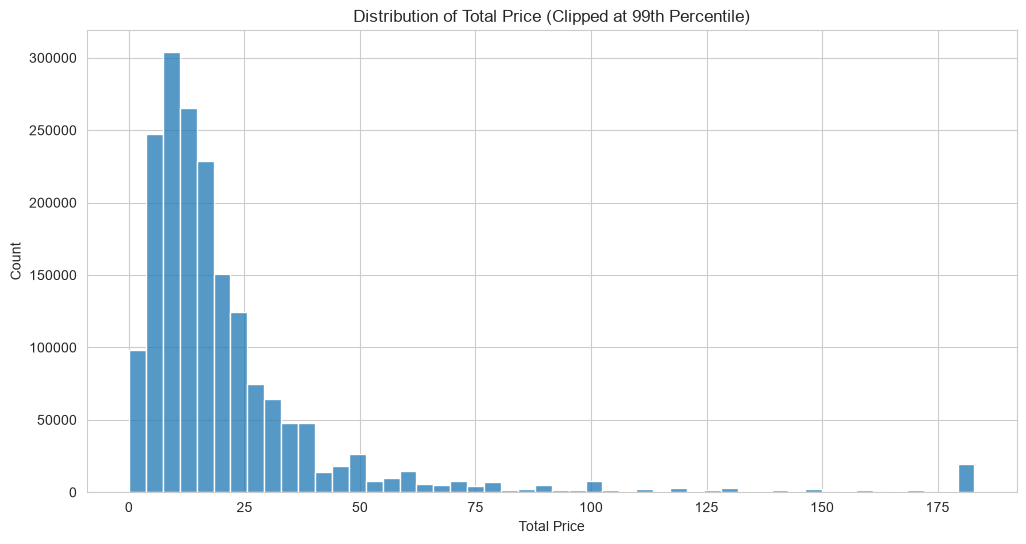

In [51]:
plt.figure(figsize=(12, 6))
sns.histplot(purchases["Total Price"].clip(upper=purchases["Total Price"].quantile(0.99)), bins=50)
plt.title("Distribution of Total Price (Clipped at 99th Percentile)")
plt.show()

**Total Price Distribution (Clipped at 99th Percentile):**

- **Observation:** The distribution is highly right-skewed. Most orders are under $50.
- **Insight:** While most customers make small purchases, a small segment of high-value spenders contributes significantly to revenue. Segmentation should separate these "High-Value Spenders" for targeted loyalty programs and cross-selling.

c. Category Distribution

In [52]:
print("Unique categories:", purchases["Category"].nunique())
print(purchases["Category"].value_counts().head(20))

Unique categories: 1872
Category
Unknown                   89201
ABIS_BOOK                 87153
PET_FOOD                  37970
SHIRT                     27143
NUTRITIONAL_SUPPLEMENT    26791
GIFT_CARD                 22985
ELECTRONIC_CABLE          18240
HEALTH_PERSONAL_CARE      16587
MEDICATION                16127
PANTS                     15924
CELLULAR_PHONE_CASE       15362
SKIN_MOISTURIZER          13630
SHOES                     12748
FOOD                      12403
GROCERY                   12084
VEGETABLE                 12057
TOYS_AND_GAMES            11591
TOY_FIGURE                11516
SKIN_CLEANING_AGENT       11389
HEADPHONES                11363
Name: count, dtype: int64


In [53]:
top20_count = purchases["Category"].value_counts().head(20).sum()
total = len(purchases)
print(f"Top 20 categories account for {top20_count} purchases, which is {top20_count / total:.2%} of total purchases.")

Top 20 categories account for 482264 purchases, which is 26.22% of total purchases.


Top 20 categories account for 482,264 purchases, which is 26.22% of total purchases. This indicates that a small number of categories dominate the purchase landscape, which can inform product assortment and marketing strategies.

=> Use **Semantic Grouping** to identify key product categories and tailor marketing efforts accordingly.

In [54]:
cat_counts_clean = purchases[purchases["Category"] != "Unknown"]["Category"].value_counts()
cat_pct_clean = purchases[purchases["Category"] != "Unknown"]["Category"].value_counts(normalize=True) * 100

significant_categories = cat_pct_clean[cat_pct_clean >= 0.05]
print("Significant Categories (>= 0.05% of total purchases):")
print(significant_categories)

df_to_map = pd.DataFrame({
    "category": significant_categories.index,
    "count": cat_counts_clean[significant_categories.index].values,
    "pct": significant_categories.values
})

df_to_map.to_csv("categories_to_map.csv", index=False)

Significant Categories (>= 0.05% of total purchases):
Category
ABIS_BOOK                 4.980479
PET_FOOD                  2.169848
SHIRT                     1.551124
NUTRITIONAL_SUPPLEMENT    1.531009
GIFT_CARD                 1.313510
                            ...   
SHOELACE                  0.050860
HAIR_DRYER                0.050803
FABRIC                    0.050289
LAB_SUPPLY                0.050232
CELL_PHONE_GRIP           0.050060
Name: proportion, Length: 419, dtype: float64


In [55]:
from category_mapping import category_mapping

purchases["Category Group"] = purchases["Category"].map(category_mapping).fillna("OTHER")
purchases.loc[purchases["Category"] == "Unknown", "Category Group"] = "Unknown"
print(purchases["Category Group"].value_counts(normalize=True) * 100)

Category Group
OTHER                            17.455724
Grocery & Food                   11.213625
Electronics & Accessories         8.608428
Home & Furniture                  8.571997
Apparel & Fashion                 8.259289
Health & Wellness                 7.372112
Beauty & Personal Care            7.096107
Books & Media                     6.456335
Unknown                           4.850271
Pet Supplies                      4.206748
Toys, Games & Hobbies             3.455290
Cleaning & Household Supplies     2.920189
Office & School Supplies          2.535598
Tools & Home Improvement          2.462790
Jewelry & Bags                    1.784738
Gift Cards                        1.658807
Sports & Outdoors                 0.864774
Baby & Maternity                  0.227177
Name: proportion, dtype: float64


The original Category column contains around 420 distinct product-level values. These categories are too granular for clear EDA and customer segmentation

Manually grouped them into 18 macro categories based on business understanding and product similarity. This grouping allows for more meaningful analysis and insights into customer behavior across broader product segments.

In [56]:
print(purchases["Category Group"].value_counts(normalize=True) * 100) 

Category Group
OTHER                            17.455724
Grocery & Food                   11.213625
Electronics & Accessories         8.608428
Home & Furniture                  8.571997
Apparel & Fashion                 8.259289
Health & Wellness                 7.372112
Beauty & Personal Care            7.096107
Books & Media                     6.456335
Unknown                           4.850271
Pet Supplies                      4.206748
Toys, Games & Hobbies             3.455290
Cleaning & Household Supplies     2.920189
Office & School Supplies          2.535598
Tools & Home Improvement          2.462790
Jewelry & Bags                    1.784738
Gift Cards                        1.658807
Sports & Outdoors                 0.864774
Baby & Maternity                  0.227177
Name: proportion, dtype: float64


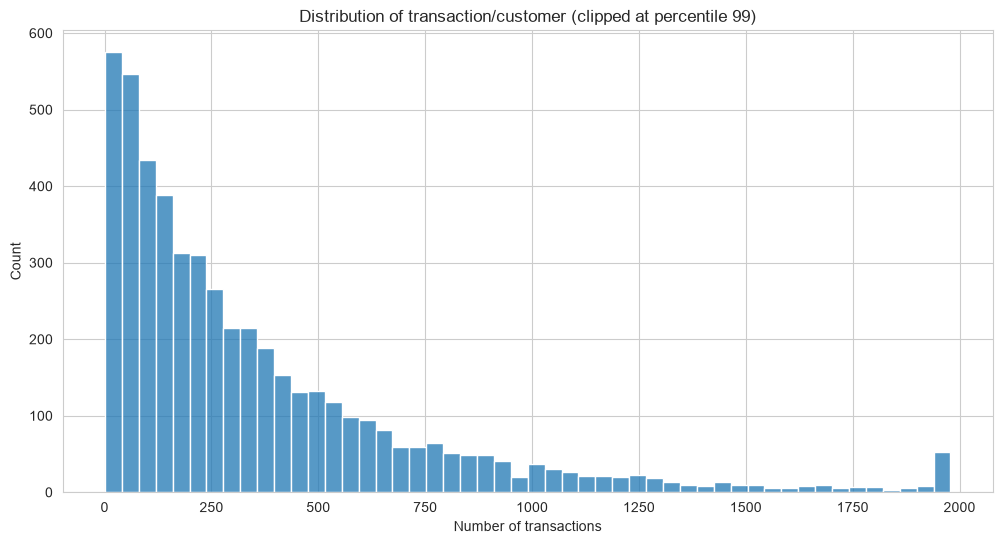

In [57]:
plt.figure(figsize=(12,6))
sns.histplot(txn_per_customer.clip(upper=txn_per_customer.quantile(0.99)), bins=50)
plt.title("Distribution of transaction/customer (clipped at percentile 99)")
plt.xlabel("Number of transactions")
plt.show()

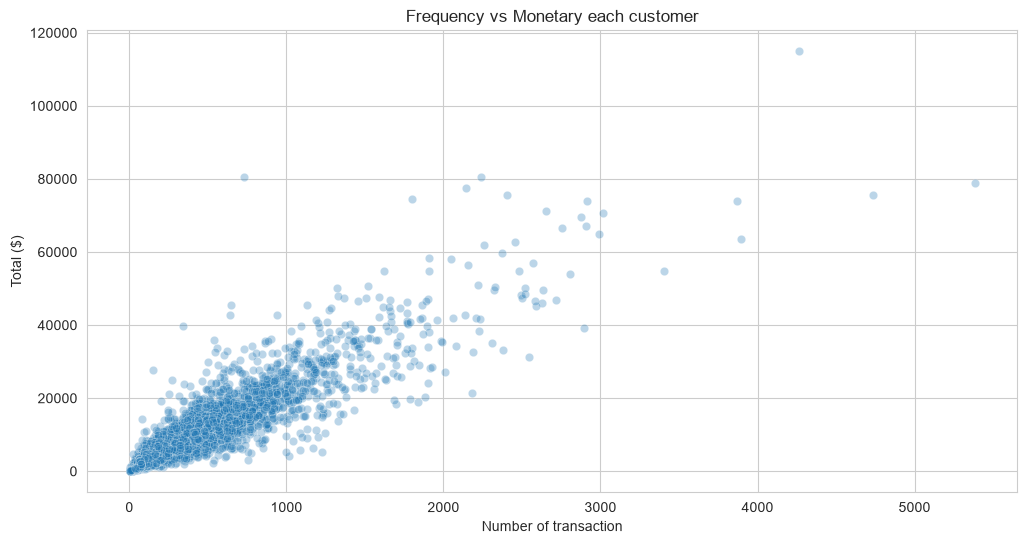

In [58]:
monetary_per_customer = purchases.groupby("Survey ResponseID")["Total Price"].sum()

rfm_check = pd.DataFrame({
    "frequency": txn_per_customer,
    "monetary": monetary_per_customer
})

plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm_check, x="frequency", y="monetary", alpha=0.3)
plt.title("Frequency vs Monetary each customer")
plt.xlabel("Number of transaction")
plt.ylabel("Total ($)")
plt.show()

**Frequency vs. Monetary Scatter Plot:**

- **Observation:** There is a positive correlation between frequency and monetary value. However, some buy often but spend little, while others buy rarely but spend a lot.
- **Insight:** Both Frequency and Monetary are crucial. Using only one metric would misidentify either frequent low-spenders or rare high-spenders. Tailored marketing is needed for each group.

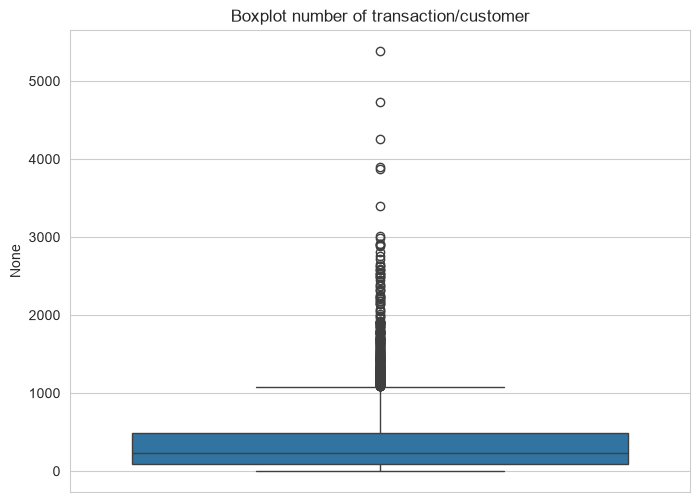

In [59]:
plt.figure(figsize=(8,6))
sns.boxplot(y=txn_per_customer)
plt.title("Boxplot number of transaction/customer")
plt.show()

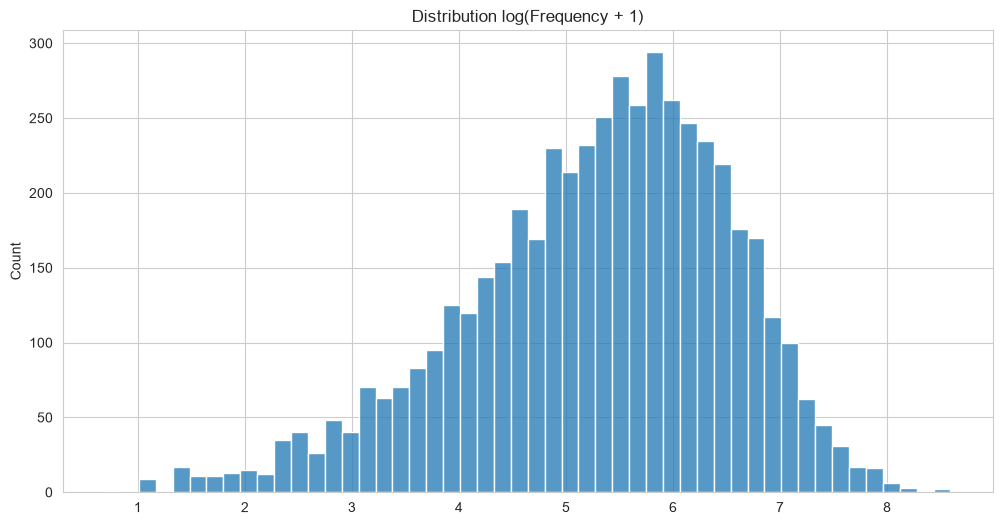

In [60]:
plt.figure(figsize=(12,6))
sns.histplot(np.log1p(txn_per_customer), bins=50)
plt.title("Distribution log(Frequency + 1)")
plt.show()

d. Transaction per Customer Distribution

In [61]:
txn_per_customer = purchases.groupby("Survey ResponseID").size()
print(txn_per_customer.describe())
print("\nMedian: ", txn_per_customer.median())
print("% of customers with 1 transaction: ", (txn_per_customer == 1).mean() * 100)

count    5027.000000
mean      365.843048
std       423.100674
min         1.000000
25%        91.000000
50%       231.000000
75%       487.000000
max      5385.000000
dtype: float64

Median:  231.0
% of customers with 1 transaction:  0.019892580067634773


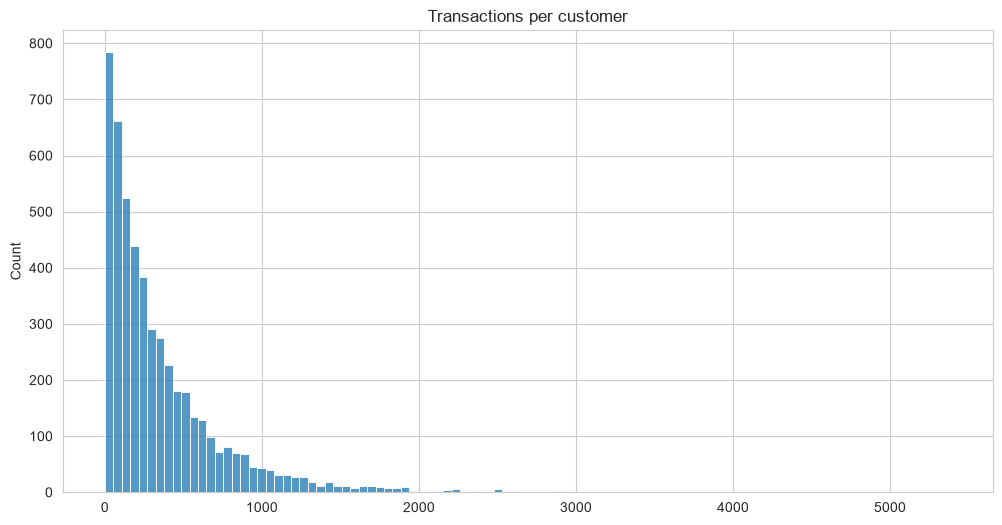

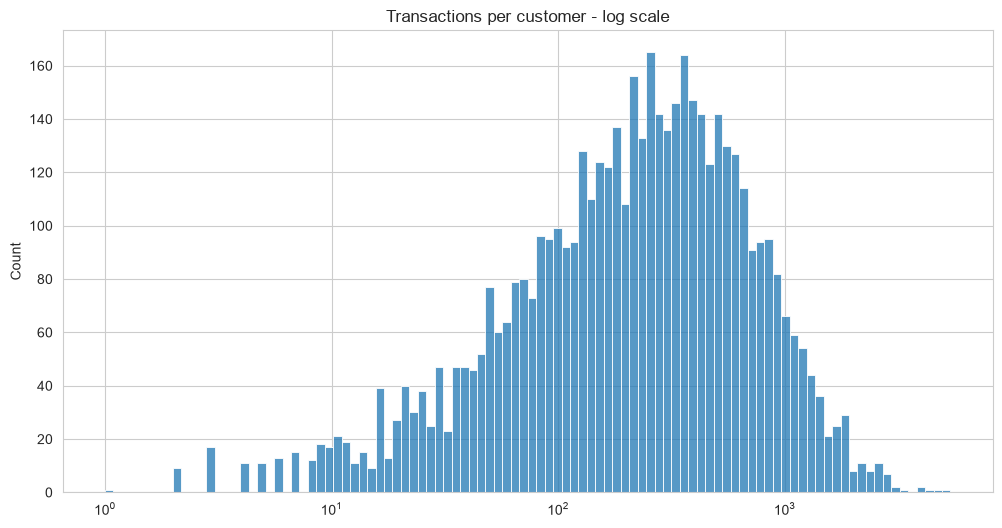

In [62]:
plt.figure(figsize=(12, 6))
sns.histplot(txn_per_customer, bins=100)
plt.title("Transactions per customer")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(txn_per_customer, bins=100, log_scale=True)
plt.title("Transactions per customer - log scale")
plt.show()

**Transactions per Customer (Frequency Distribution):**

- **Observation:** Boxplots reveal massive outliers (e.g., thousands of transactions), likely wholesale or corporate accounts. Log transformation makes the long-tail distribution clearer.
- **Insight:** The high variance indicates many one-time buyers (retention challenge) alongside extreme power users. Frequency should be carefully scaled (e.g., using log transformation) before applying clustering algorithms like K-Means to prevent centroids from being skewed by outliers.

e. Customer match (Purchases & Survey)

In [64]:
purchase_ids = set(purchases["Survey ResponseID"].unique())
survey_ids = set(survey["Survey ResponseID"].unique())

print("Unique customer in purchases:", len(purchase_ids))
print("Unique customer in survey:", len(survey_ids))
print("In purchases but NOT IN survey:", len(purchase_ids - survey_ids))
print("IN survey but NO purchase:", len(survey_ids - purchase_ids))

Unique customer in purchases: 5027
Unique customer in survey: 5027
In purchases but NOT IN survey: 0
IN survey but NO purchase: 0
